In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


RANDOM_SEED = 52

In [19]:
# utils.py
from typing_extensions import TypedDict 

import numpy as np
import numpy.typing as npt


class ConvergenceHistory(TypedDict):
    """
    TypedDict to store the convergence history of training and validation losses.

    Attributes
    ----------
    train : list[float]
        A list of training losses over epochs.
    val : list[float] | None, optional
        A list of validation losses over epochs. Defaults to None.
    """

    train: list[float]
    val: list[float] | None = None


def rmsle(y: npt.NDArray[np.float64], z: npt.NDArray[np.float64]) -> np.float64:
    """
    Calculate the Root Mean Squared Logarithmic Error (RMSLE) between two arrays.

    RMSLE is a metric that is often used in regression problems where the target variable
    is continuous and non-negative. It is particularly useful when the target variable
    spans several orders of magnitude.

    Args
    ----
    y : npt.NDArray[np.float64]
        The true values.
    z : npt.NDArray[np.float64]
        The predicted values.

    Returns
    -------
    float
        The RMSLE value.
    """
    res = np.sqrt(np.mean((np.log1p(y) - np.log1p(z)) ** 2))
    return float(res)


def whether_to_stop(convergence_history: ConvergenceHistory, patience: int) -> bool:
    """
    Determine whether to stop training based on the convergence history.

    This function checks if the training or validation loss has not improved for a
    specified number of epochs (patience). If the validation loss history is provided,
    it is used for the decision; otherwise, the training loss history is used.

    Args
    ----
    convergence_history : ConvergenceHistory
        A dictionary containing the training loss history and optionally the validation
        loss history.
    patience : int
        The number of epochs to wait after the last time the loss improved before
        stopping the training.

    Returns
    -------
    bool
        True if training should be stopped, False otherwise.

    Raises
    ------
    KeyError
        If neither 'train' nor 'val' key is present in the convergence_history.
    """
    
    if 'val' in convergence_history and convergence_history['val'] is not None:
        history = convergence_history['val']
    elif 'train' in convergence_history:
        history = convergence_history['train']
    else:
        raise KeyError("Neither 'train' nor 'val' key is present in the convergence_history.")
    
    if len(history) <= patience:
        return False
    
    best_loss = min(history[:-patience])
    
    recent_losses = history[-patience:]

    return all(loss >= best_loss for loss in recent_losses)


In [20]:
# ramdom_forest.py
import json
from pathlib import Path
from typing import Any

import joblib
import numpy as np
import numpy.typing as npt
from sklearn.tree import DecisionTreeRegressor


class RandomForestMSE:
    def __init__(
        self, n_estimators: int, tree_params: dict[str, Any] | None = None
    ) -> None:
        """
        Handmade random forest regressor.

        Classic ML algorithm that trains a set of independent tall decision trees and averages its predictions. Employs scikit-learn `DecisionTreeRegressor` under the hood.

        Args:
            n_estimators (int): Number of trees in the forest.
            tree_params (dict[str, Any] | None, optional): Parameters for sklearn trees. Defaults to None.
        """
        self.n_estimators = n_estimators
        if tree_params is None:
            tree_params = {}
        self.forest = [
            DecisionTreeRegressor(**tree_params) for _ in range(n_estimators)
        ]

    def fit(
        self,
        X: npt.NDArray[np.float64],
        y: npt.NDArray[np.float64],
        X_val: npt.NDArray[np.float64] | None = None,
        y_val: npt.NDArray[np.float64] | None = None,
        trace: bool | None = None,
        patience: int | None = None,
    ) -> ConvergenceHistory | None:
        """
        Train an ensemble of trees on the provided data.

        Args:
            X (npt.NDArray[np.float64]): Objects features matrix, array of shape (n_objects, n_features).
            y (npt.NDArray[np.float64]): Regression labels, array of shape (n_objects,).
            X_val (npt.NDArray[np.float64] | None, optional): Validation set of objects, array of shape (n_val_objects, n_features). Defaults to None.
            y_val (npt.NDArray[np.float64] | None, optional): Validation set of labels, array of shape (n_val_objects,). Defaults to None.
            trace (bool | None, optional): Whether to calculate rmsle while training. True by default if validation data is provided. Defaults to None.
            patience (int | None, optional): Number of training steps without decreasing the train loss (or validation if provided), after which to stop training. Defaults to None.

        Returns:
            ConvergenceHistory | None: Instance of `ConvergenceHistory` if `trace=True` or if validation data is provided.
        """
        
        if trace is None:
            trace = X_val is not None and y_val is not None

        y_log = np.log1p(y)
        y_val_log = np.log1p(y_val) if y_val is not None else None

        history: ConvergenceHistory | None = None
        if trace: 
            history = {'train': [], 'val': [] if X_val is not None else None}

        n_objects = X.shape[0]
        n_trained = 0

        train_sum = np.zeros_like(y_log, dtype=np.float64)
        val_sum = np.zeros_like(y_val_log, dtype=np.float64) if y_val is not None else None

        for tree in self.forest:
            idx = np.random.choice(n_objects, size=n_objects, replace=True)
            tree.fit(X.iloc[idx] if hasattr(X, 'iloc') else X[idx], y_log.iloc[idx] if hasattr(y_log, 'iloc') else y_log[idx])

            y_pred_new_train = tree.predict(X)
            train_sum += y_pred_new_train

            if X_val is not None:
                y_pred_new_val = tree.predict(X_val)
                val_sum += y_pred_new_val

            n_trained += 1

            if trace:
                avg_train_pred_log = train_sum / n_trained
                loss_train = rmsle(y, np.expm1(avg_train_pred_log))
                history['train'].append(loss_train)

                if X_val is not None:
                    avg_val_pred_log = val_sum / n_trained
                    loss_val = rmsle(y_val, np.expm1(avg_val_pred_log))
                    history['val'].append(loss_val)

                if patience is not None and whether_to_stop(history, patience):
                    break

        return history


    def predict(self, X: npt.NDArray[np.float64]) -> npt.NDArray[np.float64]:
        """
        Make prediction with ensemble of trees.

        All the trees make their own predictions which then are averaged.

        Args:
            X (npt.NDArray[np.float64]): Objects' features matrix, array of shape (n_objects, n_features).

        Returns:
            npt.NDArray[np.float64]: Predicted values, array of shape (n_objects,).
        """
        preds_log = np.zeros(X.shape[0], dtype=np.float64)
        n_trained_trees = 0
        for tree in self.forest:
            if hasattr(tree, 'tree_'):
                preds_log += tree.predict(X)
                n_trained_trees += 1

        if n_trained_trees == 0:
            raise RuntimeError('Cannot predict: no trained trees in the forest.')

        return np.expm1(preds_log / n_trained_trees)

    def dump(self, dirpath: str) -> None:
        """
        Save the trained model to the specified directory.

        Args:
            dirpath (str): Path to the directory where the model will be saved.
        """
        path = Path(dirpath)
        path.mkdir(parents=True)

        params = {"n_estimators": self.n_estimators}
        with (path / "params.json").open("w") as file:
            json.dump(params, file, indent=4)

        trees_path = path / "trees"
        trees_path.mkdir()
        for i, tree in enumerate(self.forest):
            joblib.dump(tree, trees_path / f"tree_{i:04d}.joblib")

    @classmethod
    def load(cls, dirpath: str) -> "RandomForestMSE":
        """
        Load a trained model from the specified directory.

        Args:
            dirpath (str): Path to the directory where the model is saved.

        Returns:
            RandomForestMSE: An instance of the loaded model.
        """
        with (Path(dirpath) / "params.json").open() as file:
            params = json.load(file)
        instance = cls(params["n_estimators"])

        trees_path = Path(dirpath) / "trees"

        instance.forest = [
            joblib.load(trees_path / f"tree_{i:04d}.joblib")
            for i in range(params["n_estimators"])
        ]

        return instance


In [21]:
# boosting
import json
from pathlib import Path
from typing import Any

import joblib
import numpy as np
import numpy.typing as npt
from sklearn.tree import DecisionTreeRegressor

class GradientBoostingMSE:
    const_prediction: float

    def __init__(
        self,
        n_estimators: int,
        tree_params: dict[str, Any] | None = None,
        learning_rate=0.1,
    ) -> None:
        """
        Initializes the GradientBoostingMSE model.

        This is a handmade gradient boosting regressor that trains a sequence of
        short decision trees to correct the errors of each other's predictions.
        It employs scikit-learn's `DecisionTreeRegressor` under the hood.

        Args:
            n_estimators (int): Number of trees to boost each other.
            tree_params (dict[str, Any] | None, optional): Parameters for the decision trees. Defaults to None.
            learning_rate (float, optional): Scaling factor for the "gradient" step (the weight applied to each tree prediction). Defaults to 0.1.
        """
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        if tree_params is None:
            tree_params = {}
        self.forest = [
            DecisionTreeRegressor(**tree_params) for _ in range(n_estimators)
        ]

    def fit(
        self,
        X: npt.NDArray[np.float64],
        y: npt.NDArray[np.float64],
        X_val: npt.NDArray[np.float64] | None = None,
        y_val: npt.NDArray[np.float64] | None = None,
        trace: bool | None = None,
        patience: int | None = None,
    ) -> ConvergenceHistory | None:
        """
        Trains an ensemble of trees on the provided data.

        Args:
            X (npt.NDArray[np.float64]): Objects features matrix, array of shape (n_objects, n_features).
            y (npt.NDArray[np.float64]): Regression labels, array of shape (n_objects,).
            X_val (npt.NDArray[np.float64] | None, optional): Validation set of objects, array of shape (n_val_objects, n_features). Defaults to None.
            y_val (npt.NDArray[np.float64] | None, optional): Validation set of labels, array of shape (n_val_objects,). Defaults to None.
            trace (bool | None, optional): Whether to calculate RMSLE while training. True by default if validation data is provided. Defaults to None.
            patience (int | None, optional): Number of training steps without decreasing the train loss (or validation if provided), after which to stop training. Defaults to None.

        Returns:
            ConvergenceHistory | None: Instance of `ConvergenceHistory` if `trace=True` or if validation data is provided.
        """

        if trace is None:
            trace = X_val is not None and y_val is not None

        y_log = np.log1p(y)
        y_val_log = np.log1p(y_val) if y_val is not None else None

        self.const_prediction = float(np.mean(y_log))

        history: ConvergenceHistory | None = None
        if trace:
            history = {'train': [], 'val': [] if X_val is not None else None}

        y_pred_log = np.full_like(y_log, self.const_prediction, dtype=np.float64)
        if y_val_log is not None:
            y_pred_val_log = np.full_like(y_val_log, self.const_prediction, dtype=np.float64)

        for tree in self.forest:
            s = y_log - y_pred_log

            tree.fit(X, s)

            y_pred_log += self.learning_rate * tree.predict(X)

            if y_val_log is not None:
                y_pred_val_log += self.learning_rate * tree.predict(X_val)

            if trace:
                pred_orig = np.expm1(y_pred_log)
                loss_train = rmsle(y, pred_orig)
                history['train'].append(loss_train)

                if y_val_log is not None:
                    pred_val_orig = np.expm1(y_pred_val_log)
                    loss_val = rmsle(y_val, pred_val_orig)
                    assert history['val'] is not None
                    history['val'].append(loss_val)

                if patience is not None and whether_to_stop(history, patience):
                    break

        return history

    def predict(self, X: npt.NDArray[np.float64]) -> npt.NDArray[np.float64]:
        """
        Makes predictions with the ensemble of trees.

        All the trees make sequential predictions.

        Args:
            X (npt.NDArray[np.float64]): Objects' features matrix, array of shape (n_objects, n_features).

        Returns:
            npt.NDArray[np.float64]: Predicted values, array of shape (n_objects,).
        """
        
        preds_log = np.full(X.shape[0], self.const_prediction, dtype=np.float64)

        for tree in self.forest:
            if hasattr(tree, "tree_"):
                preds_log += self.learning_rate * tree.predict(X)

        return np.expm1(preds_log)


    def dump(self, dirpath: str) -> None:
        """
        Saves the model to the specified directory.

        Args:
            dirpath (str): Path to the directory where the model will be saved.
        """
        path = Path(dirpath)
        path.mkdir(parents=True)

        params = {
            "n_estimators": self.n_estimators,
            "learning_rate": self.learning_rate,
            "const_prediction": self.const_prediction,
        }
        with (path / "params.json").open("w") as file:
            json.dump(params, file, indent=4)

        trees_path = path / "trees"
        trees_path.mkdir()
        for i, tree in enumerate(self.forest):
            joblib.dump(tree, trees_path / f"tree_{i:04d}.joblib")

    @classmethod
    def load(cls, dirpath: str) -> "GradientBoostingMSE":
        """
        Loads the model from the specified directory.

        Args:
            dirpath (str): Path to the directory where the model is saved.

        Returns:
            GradientBoostingMSE: An instance of the GradientBoostingMSE model.
        """
        with (Path(dirpath) / "params.json").open() as file:
            params = json.load(file)
        instance = cls(params["n_estimators"], learning_rate=params["learning_rate"])

        trees_path = Path(dirpath) / "trees"

        instance.forest = [
            joblib.load(trees_path / f"tree_{i:04d}.joblib")
            for i in range(params["n_estimators"])
        ]
        instance.const_prediction = params["const_prediction"]

        return instance


In [22]:
data = pd.read_csv('kc_house_data.csv')

In [23]:
data

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [24]:
data.isna().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [25]:
data = data.drop(columns=['id', 'date'])
X = data.drop(columns=['price'])
y = data['price']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

In [26]:
print(f'{X_train.shape=}, {X_val.shape=}') 

X_train.shape=(17290, 18), X_val.shape=(4323, 18)


In [27]:
data

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,3,2.50,1530,1131,3.0,0,0,3,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,400000.0,4,2.50,2310,5813,2.0,0,0,3,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,402101.0,2,0.75,1020,1350,2.0,0,0,3,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,400000.0,3,2.50,1600,2388,2.0,0,0,3,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


# Случайный лес


In [81]:
n_estimators_fixed = 50

max_depth_list = [3, 5, 8, 12, 20, None]
max_features_list = max_features_values = [1, 2, 3, 4, 5, 6, 9, 12, 15, 18]
results_params_forest = []

total_iterations = len(max_depth_list) * len(max_features_list)
pbar = tqdm(total=total_iterations, desc="Random Forest calc")
for max_depth in max_depth_list:
    for max_features in max_features_list:
        rf = RandomForestMSE(
            n_estimators=n_estimators_fixed,
            tree_params={"max_depth": max_depth, "max_features": max_features}
        )
        
        start_time = time.time()
        rf.fit(X_train, y_train, X_val, y_val, trace=True)
        duration = time.time() - start_time
        
        y_pred = rf.predict(X_val)
        rmse_val = rmsle(y_val, y_pred)
        
        results_params_forest.append({
            "max_depth": max_depth,
            "max_features": max_features,
                "rmse_val": rmse_val,
            "time": duration
        })
        pbar.update(1)
pbar.close()

df_params = pd.DataFrame(results_params_forest)
print(df_params)

Random Forest calc: 100%|███████████████████████| 60/60 [02:36<00:00,  2.61s/it]

    max_depth  max_features  rmse_val      time
0         3.0             1  0.379845  0.500413
1         3.0             2  0.337698  0.537104
2         3.0             3  0.304118  0.617808
3         3.0             4  0.293232  0.703445
4         3.0             5  0.288077  0.789258
5         3.0             6  0.285089  0.860055
6         3.0             9  0.275807  1.104984
7         3.0            12  0.275179  1.323248
8         3.0            15  0.282212  1.575939
9         3.0            18  0.293875  1.813877
10        5.0             1  0.330806  0.524645
11        5.0             2  0.275415  0.665566
12        5.0             3  0.262588  0.795540
13        5.0             4  0.246003  0.933997
14        5.0             5  0.240100  1.063832
15        5.0             6  0.236351  1.192263
16        5.0             9  0.231673  1.592634
17        5.0            12  0.232102  1.985605
18        5.0            15  0.232007  2.381965
19        5.0            18  0.240731  2

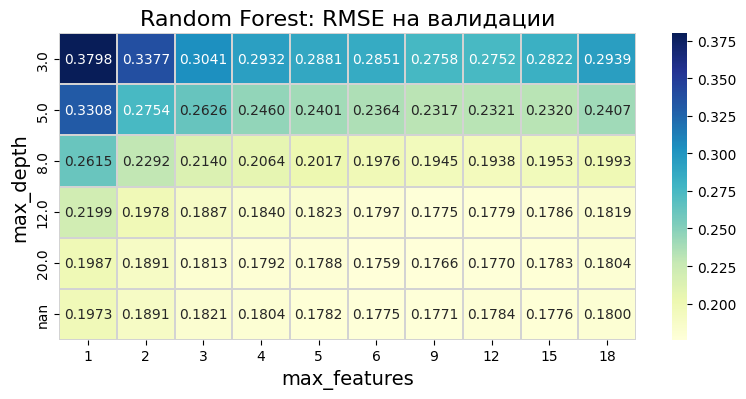

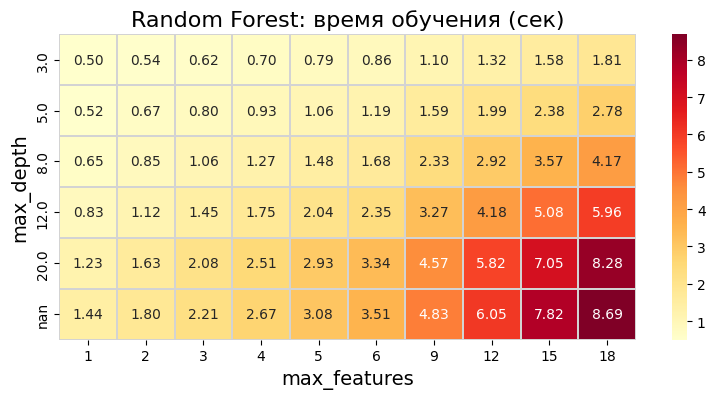

In [196]:
rmse_pivot = df_params.pivot(index='max_depth', columns='max_features', values='rmse_val')
time_pivot = df_params.pivot(index='max_depth', columns='max_features', values='time')

rmse_pivot = rmse_pivot.reindex(index=max_depth_list, columns=max_features_list)
time_pivot = time_pivot.reindex(index=max_depth_list, columns=max_features_list)

plt.figure(figsize=(8, 4.1))

sns.heatmap(rmse_pivot, annot=True, fmt=".4f", cmap="YlGnBu", linewidths=0.01, linecolor='lightgray')
plt.title("Random Forest: RMSE на валидации", fontsize=16)
plt.xlabel("max_features", fontsize=14)
plt.ylabel("max_depth", fontsize=14)

plt.tight_layout()
plt.savefig('exp11.pdf', bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 4.1))

sns.heatmap(time_pivot, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.01, linecolor='lightgray')
plt.title("Random Forest: время обучения (сек)", fontsize=16)
plt.xlabel("max_features", fontsize=14)
plt.ylabel("max_depth", fontsize=14)

plt.tight_layout()
plt.savefig('exp12.pdf', bbox_inches='tight')
plt.show()


In [189]:
best_max_depth = 20
best_max_features = 6
n_estimators_list = [5, 10, 20, 50, 100, 200, 500, 1000]

results_trees = []

for n_trees in n_estimators_list:
    print(f"Обучаем лес с {n_trees} деревьями...")
    rf = RandomForestMSE(
        n_estimators=n_trees,
        tree_params={
            "max_depth": best_max_depth,
            "max_features": best_max_features
        }
    )
    start_time = time.time()
    rf.fit(X_train, y_train, X_val, y_val, trace=True)
    duration = time.time() - start_time
    
    y_pred = rf.predict(X_val)
    rmse_val = rmsle(y_val, y_pred)
    
    results_trees.append({
        "n_estimators": n_trees,
        "rmse_val": rmse_val,
        "time": duration
    })

df_trees = pd.DataFrame(results_trees)
print(df_trees)


Обучаем лес с 5 деревьями...
Обучаем лес с 10 деревьями...
Обучаем лес с 20 деревьями...
Обучаем лес с 50 деревьями...
Обучаем лес с 100 деревьями...
Обучаем лес с 200 деревьями...
Обучаем лес с 500 деревьями...
Обучаем лес с 1000 деревьями...
   n_estimators  rmse_val       time
0             5  0.200868   0.343040
1            10  0.187956   0.671748
2            20  0.181378   1.357877
3            50  0.177429   3.395045
4           100  0.176407   6.759576
5           200  0.176272  13.626333
6           500  0.175430  34.018255
7          1000  0.174988  69.930715


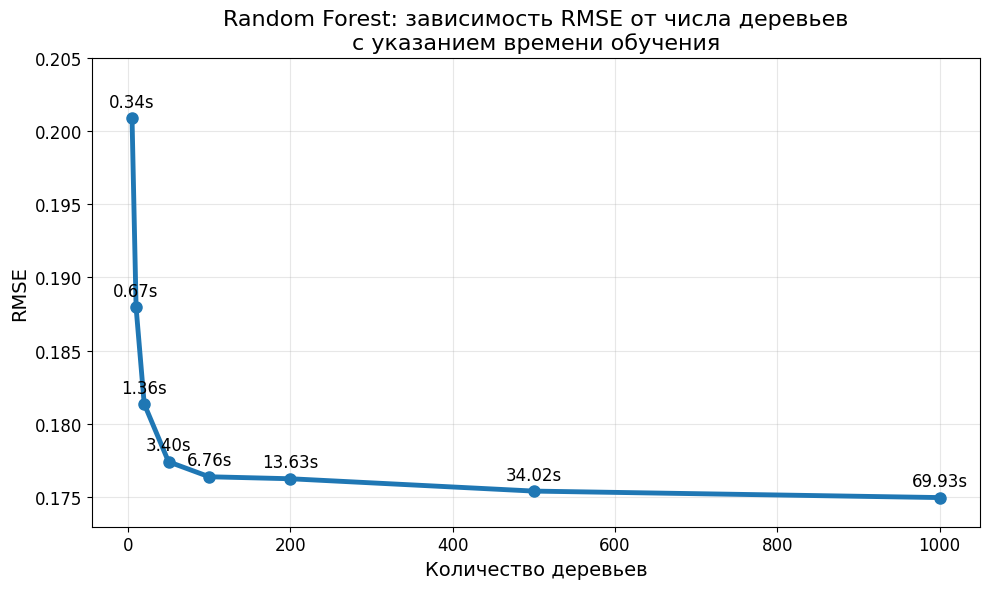

In [192]:
plt.figure(figsize=(10, 6))
plt.plot(df_trees['n_estimators'], df_trees['rmse_val'], marker='o', linewidth=3.5, markersize=8)

for i, row in df_trees.iterrows():
    plt.text(row['n_estimators'], row['rmse_val']+ 0.0005 , f"{row['time']:.2f}s", ha='center', va='bottom', fontsize=12)

plt.xlabel("Количество деревьев", fontsize=14)
plt.ylabel("RMSE", fontsize=14)
plt.ylim(0.173, 0.205)
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12)  

plt.title("Random Forest: зависимость RMSE от числа деревьев\nс указанием времени обучения", fontsize=16)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('exp13.pdf', bbox_inches='tight')
plt.show()


# Бустинг


In [193]:
n_estimators_fixed = 50
learning_rate_fixed = 0.1

max_depth_list = [3, 5, 8, 12, 20, None]
max_features_list = [1, 2, 3, 4, 5, 6, 9, 12, 15, 18]

results_params_boosting = []

total_iterations = len(max_depth_list) * len(max_features_list)
pbar = tqdm(total=total_iterations, desc="Boosting calc")
for max_depth in max_depth_list:
    for max_features in max_features_list:
        gb = GradientBoostingMSE(
            n_estimators=n_estimators_fixed,
            learning_rate=learning_rate_fixed,
            tree_params={"max_depth": max_depth, "max_features": max_features}
        )
        
        start_time = time.time()
        gb.fit(X_train, y_train, X_val, y_val, trace=True)
        duration = time.time() - start_time
        
        y_pred = gb.predict(X_val)
        rmse_val = rmsle(y_val, y_pred)
        
        results_params_boosting.append({
            "max_depth": max_depth,
            "max_features": max_features,
            "rmse_val": rmse_val,
            "time": duration
        })
        pbar.update(1)
pbar.close()

df_params_boosting = pd.DataFrame(results_params_boosting)
print(df_params_boosting)


Boosting calc: 100%|████████████████████████████| 60/60 [03:03<00:00,  3.06s/it]

    max_depth  max_features  rmse_val       time
0         3.0             1  0.246672   0.390121
1         3.0             2  0.218786   0.469947
2         3.0             3  0.212256   0.548840
3         3.0             4  0.209316   1.107550
4         3.0             5  0.201614   0.713215
5         3.0             6  0.201165   0.811069
6         3.0             9  0.198346   1.089405
7         3.0            12  0.199240   1.823172
8         3.0            15  0.197069   1.584066
9         3.0            18  0.198007   1.868948
10        5.0             1  0.216256   0.951904
11        5.0             2  0.198521   0.601262
12        5.0             3  0.187383   0.749260
13        5.0             4  0.183112   0.896902
14        5.0             5  0.180909   1.048981
15        5.0             6  0.180576   1.209650
16        5.0             9  0.177943   1.644683
17        5.0            12  0.176126   2.096119
18        5.0            15  0.175068   2.492027
19        5.0       

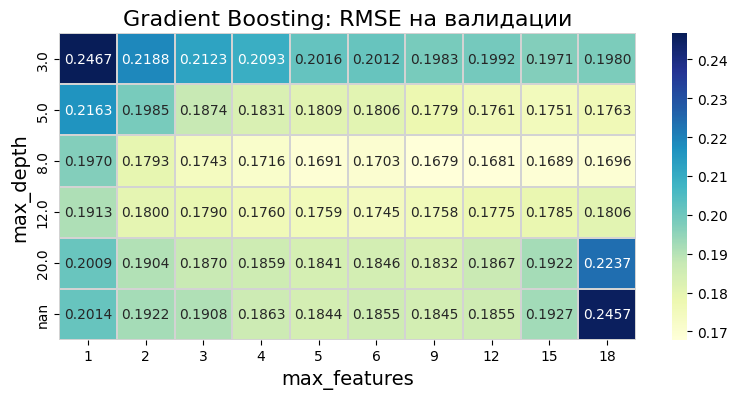

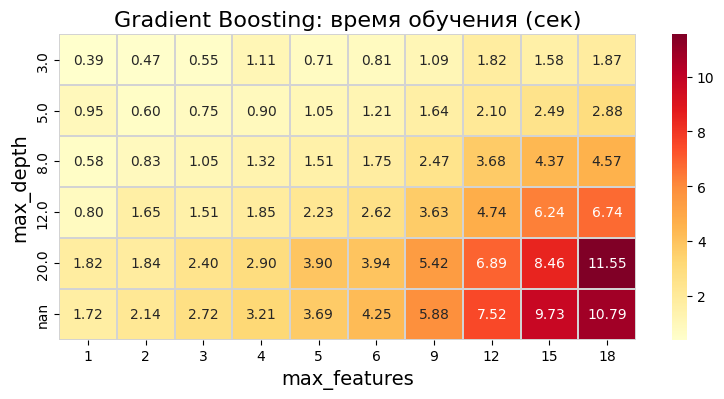

In [195]:
rmse_pivot = df_params_boosting.pivot(index='max_depth', columns='max_features', values='rmse_val')
time_pivot = df_params_boosting.pivot(index='max_depth', columns='max_features', values='time')

rmse_pivot = rmse_pivot.reindex(index=max_depth_list, columns=max_features_list)
time_pivot = time_pivot.reindex(index=max_depth_list, columns=max_features_list)

plt.figure(figsize=(8, 4.1))

sns.heatmap(rmse_pivot, annot=True, fmt=".4f", cmap="YlGnBu", linewidths=0.01, linecolor='lightgray')
plt.title("Gradient Boosting: RMSE на валидации", fontsize=16)
plt.xlabel("max_features", fontsize=14)
plt.ylabel("max_depth", fontsize=14)

plt.tight_layout()
plt.savefig('exp21.pdf', bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 4.1))

sns.heatmap(time_pivot, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.01, linecolor='lightgray')
plt.title("Gradient Boosting: время обучения (сек)", fontsize=16)
plt.xlabel("max_features", fontsize=14)
plt.ylabel("max_depth", fontsize=14)

plt.tight_layout()
plt.savefig('exp22.pdf', bbox_inches='tight')
plt.show()


In [228]:
best_max_depth = 8
best_max_features = 9
learning_rate_fixed = 0.1 

n_estimators_list = [5, 10, 20, 50, 100, 200, 500, 1000]
results_trees_boosting = []
for n_trees in n_estimators_list:
    print(f"Обучаем GradientBoostingMSE с {n_trees} деревьями...")
    
    gb_model = GradientBoostingMSE(
        n_estimators=n_trees,
        learning_rate=learning_rate_fixed,
        tree_params={"max_depth": best_max_depth, "max_features": best_max_features}
    )
    
    start_time = time.time()
    history = gb_model.fit(X_train, y_train, trace=True) 
    fit_time = time.time() - start_time

    y_pred = gb_model.predict(X_val)
    rmse_val = rmsle(y_val, y_pred)
    
    results_trees_boosting.append({
        "n_estimators": n_trees,
        "rmse_val": rmse_val,
        "time": fit_time  
    })


df_trees_boosting = pd.DataFrame(results_trees_boosting)
print(df_trees_boosting)

Обучаем GradientBoostingMSE с 5 деревьями...
Обучаем GradientBoostingMSE с 10 деревьями...
Обучаем GradientBoostingMSE с 20 деревьями...
Обучаем GradientBoostingMSE с 50 деревьями...
Обучаем GradientBoostingMSE с 100 деревьями...
Обучаем GradientBoostingMSE с 200 деревьями...
Обучаем GradientBoostingMSE с 500 деревьями...
Обучаем GradientBoostingMSE с 1000 деревьями...
   n_estimators  rmse_val       time
0             5  0.355446   0.249525
1            10  0.262854   0.987267
2            20  0.191239   1.014308
3            50  0.168135   3.042699
4           100  0.166924   5.966545
5           200  0.167280  12.352353
6           500  0.169370  30.234959
7          1000  0.172312  56.929698


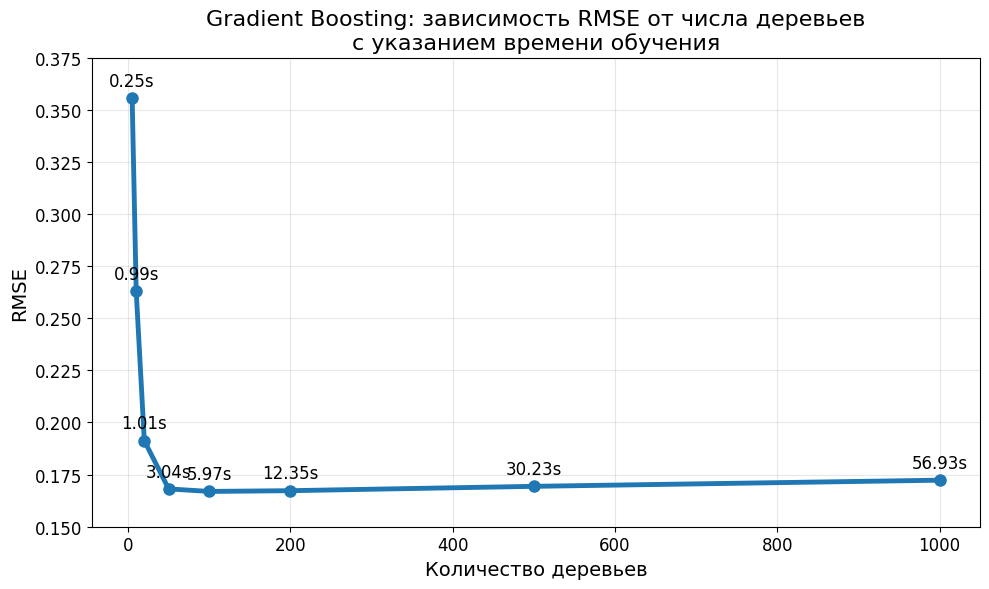

In [229]:
plt.figure(figsize=(10, 6))
plt.plot(df_trees_boosting['n_estimators'], df_trees_boosting['rmse_val'], marker='o', linewidth=3.5, markersize=8)

for i, row in df_trees_boosting.iterrows():
    plt.text(row['n_estimators'], row['rmse_val']+ 0.004 , f"{row['time']:.2f}s", ha='center', va='bottom', fontsize=12)

plt.xlabel("Количество деревьев", fontsize=14)
plt.ylabel("RMSE", fontsize=14)
plt.ylim(0.15, 0.375)
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12)  

plt.title("Gradient Boosting: зависимость RMSE от числа деревьев\nс указанием времени обучения", fontsize=16)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('exp23.pdf', bbox_inches='tight')
plt.show()


In [30]:
best_n_estimators = 100
best_max_depth = 8
best_max_features = 9

learning_rate_list = [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.3]
results_lr = []

for lr in learning_rate_list:
    gb = GradientBoostingMSE(
        n_estimators=best_n_estimators,
        learning_rate=lr,
        tree_params={"max_depth": best_max_depth, "max_features": best_max_features}
    )
    start_time = time.time()
    gb.fit(X_train, y_train, X_val, y_val, trace=True)
    duration = time.time() - start_time
    
    y_pred = gb.predict(X_val)
    rmse_val = rmsle(y_val, y_pred)
    
    results_lr.append({
        "learning_rate": lr,
        "rmse_val": rmse_val,
        "time": duration
    })

df_lr = pd.DataFrame(results_lr)
print(df_lr)
# перезапустил ячейку, поэтому цифры в отчете могут быть немного другими

   learning_rate  rmse_val      time
0           0.01  0.266487  4.843787
1           0.03  0.173430  4.787184
2           0.05  0.166473  4.739057
3           0.10  0.165115  4.772544
4           0.15  0.167209  4.800620
5           0.20  0.172590  5.388336
6           0.30  0.179980  5.333631


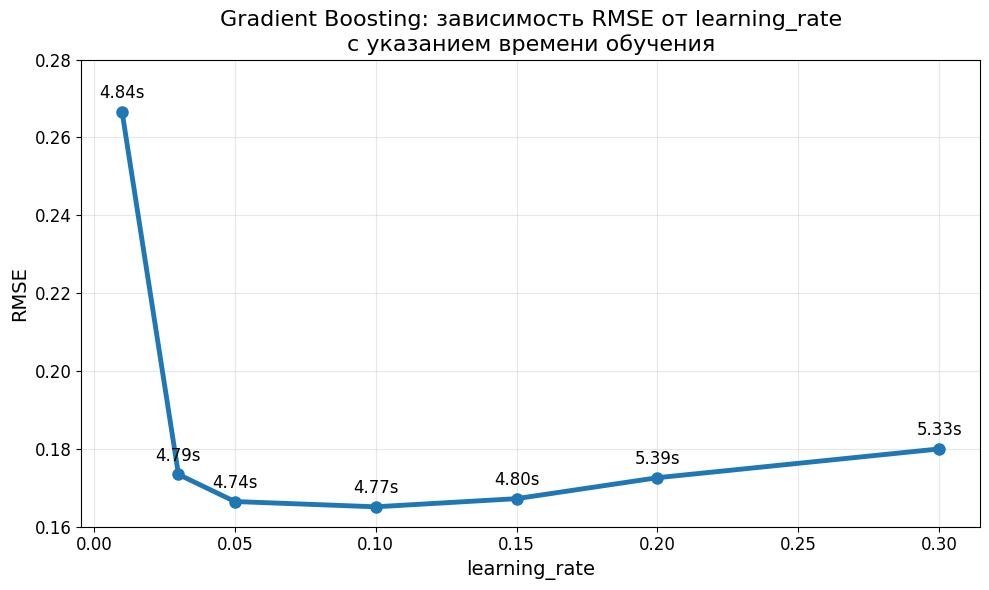

In [31]:
plt.figure(figsize=(10, 6))
plt.plot(df_lr["learning_rate"], df_lr["rmse_val"], marker='o', linewidth=3.5, markersize=8)

for i, row in df_lr.iterrows():
    plt.text(row["learning_rate"], row["rmse_val"] + 0.0025, f"{row['time']:.2f}s", ha='center', va='bottom', fontsize=12)

plt.xlabel("learning_rate", fontsize=14)
plt.ylabel("RMSE", fontsize=14)
plt.ylim(0.16, 0.28)
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12)  

plt.title("Gradient Boosting: зависимость RMSE от learning_rate\nс указанием времени обучения", fontsize=16)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('exp24.pdf', bbox_inches='tight')
plt.show()
